In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import datetime as dt
import plotly.express as px

In [133]:
try:
    df_assessment: pd.DataFrame = pd.read_csv(
        "data/assessments_G5P3.csv",
    )
    # df_delivery: pd.DataFrame = pd.read_csv("dummy_stuff/dummy_delivery.csv")
    # df_logs: pd.DataFrame = pd.read_csv("dummy_stuff/dummy_logs.csv")
except FileNotFoundError as e:
    raise FileNotFoundError(f"Error: {e}. Please ensure the CSV files are in the correct directory.")
except pd.errors.EmptyDataError as e:
    raise ValueError(f"Error: {e}. The CSV files are empty. Please provide valid data.")

df_assessment.head()

,assessment_code,assessment_name,module_code,module_name,date_released,date_due,recommended_hours,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,ZDAT1001_13102025,Portfolio 1,ZDAT1001,Software Portfolio Assessment,13-Oct-25,19-Nov-25,20.0,NaN,NaN,NaN,NaN,NaN
1,ZDAT1001_15012026,Portfolio 2,ZDAT1001,Software Portfolio Assessment,15-Jan-26,22-Apr-26,35.0,NaN,NaN,NaN,NaN,NaN
2,ZDAT1001_21042026,Portfolio 3,ZDAT1001,Software Portfolio Assessment,21-Apr-26,17-Jun-26,45.0,NaN,NaN,NaN,NaN,NaN
3,ZDAT1002_07012026,Assignment 1 ? Data Science Pipeline Report,ZDAT1002,Fundamental Skills Assessment,07-Jan-26,18-Feb-26,12.0,NaN,NaN,NaN,NaN,NaN
4,ZDAT1002_08022026,Assignment 2 ? Maths Portfolio,ZDAT1002,Fundamental Skills Assessment,08-Feb-26,09-Jun-26,15.0,NaN,NaN,NaN,NaN,NaN


In [134]:
# clean date columns in df_assessment
df_assessment['date_released'] = pd.to_datetime(df_assessment['date_released'], format="%d-%b-%y", errors='coerce')
df_assessment['date_due'] = pd.to_datetime(df_assessment['date_due'], format="%d-%b-%y", errors='coerce')
df_assessment["category"] = df_assessment["recommended_hours"].apply(
    lambda x: "High" if x > 7.4 else ("Medium" if x > 4 else "Low")
)

In [135]:
df_assessment.head()

,assessment_code,assessment_name,module_code,module_name,date_released,date_due,recommended_hours,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,category
0,ZDAT1001_13102025,Portfolio 1,ZDAT1001,Software Portfolio Assessment,2025-10-13,2025-11-19,20.0,NaN,NaN,NaN,NaN,NaN,High
1,ZDAT1001_15012026,Portfolio 2,ZDAT1001,Software Portfolio Assessment,2026-01-15,2026-04-22,35.0,NaN,NaN,NaN,NaN,NaN,High
2,ZDAT1001_21042026,Portfolio 3,ZDAT1001,Software Portfolio Assessment,2026-04-21,2026-06-17,45.0,NaN,NaN,NaN,NaN,NaN,High
3,ZDAT1002_07012026,Assignment 1 ? Data Science Pipeline Report,ZDAT1002,Fundamental Skills Assessment,2026-01-07,2026-02-18,12.0,NaN,NaN,NaN,NaN,NaN,High
4,ZDAT1002_08022026,Assignment 2 ? Maths Portfolio,ZDAT1002,Fundamental Skills Assessment,2026-02-08,2026-06-09,15.0,NaN,NaN,NaN,NaN,NaN,High


In [136]:
# filter to only include rows which include time taken in assessment
fig = px.timeline(
    df_assessment,
    x_start="date_released",
    x_end="date_due",
    color="category",
    hover_name="module_code",
    color_discrete_map={"Low": "#66bb6a", "Medium": "#ffca28", "High": "#ef5350"},
)

fig.update_yaxes(autorange="reversed")

fig.update_layout(
    title="Apprenticeship Timeline",
    xaxis_title="Date",
    yaxis_title="Activity",
    height=450,
)

fig.show()

In [137]:
df_assessment["month"] = df_assessment["date_released"].dt.month_name()
df_assessment["year"] = df_assessment["date_released"].dt.year
heat_df = (
    df_assessment.groupby(["year", "month"])["recommended_hours"].sum().reset_index()
)
df_assessment.head()

,assessment_code,assessment_name,module_code,module_name,date_released,date_due,recommended_hours,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,category,month,year
0,ZDAT1001_13102025,Portfolio 1,ZDAT1001,Software Portfolio Assessment,2025-10-13,2025-11-19,20.0,NaN,NaN,NaN,NaN,NaN,High,October,2025.0
1,ZDAT1001_15012026,Portfolio 2,ZDAT1001,Software Portfolio Assessment,2026-01-15,2026-04-22,35.0,NaN,NaN,NaN,NaN,NaN,High,January,2026.0
2,ZDAT1001_21042026,Portfolio 3,ZDAT1001,Software Portfolio Assessment,2026-04-21,2026-06-17,45.0,NaN,NaN,NaN,NaN,NaN,High,April,2026.0
3,ZDAT1002_07012026,Assignment 1 ? Data Science Pipeline Report,ZDAT1002,Fundamental Skills Assessment,2026-01-07,2026-02-18,12.0,NaN,NaN,NaN,NaN,NaN,High,January,2026.0
4,ZDAT1002_08022026,Assignment 2 ? Maths Portfolio,ZDAT1002,Fundamental Skills Assessment,2026-02-08,2026-06-09,15.0,NaN,NaN,NaN,NaN,NaN,High,February,2026.0


In [138]:
month_order = [
    "October",
    "November",
    "December",
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
]

heat_df["month"] = pd.Categorical(
    heat_df["month"], categories=month_order, ordered=True
)
heat_df = heat_df.sort_values(["year", "month"])

In [139]:
heat_matrix = heat_df.pivot(
    index="year", columns="month", values="recommended_hours"
).fillna(0)
heat_matrix

month,October,November,September,January,February,March,April,May,June,July
year,,,,,,,,,,
2025.0,176.0,40.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026.0,0.0,0.0,0.0,67.0,17.0,71.0,139.0,8.0,205.0,78.0


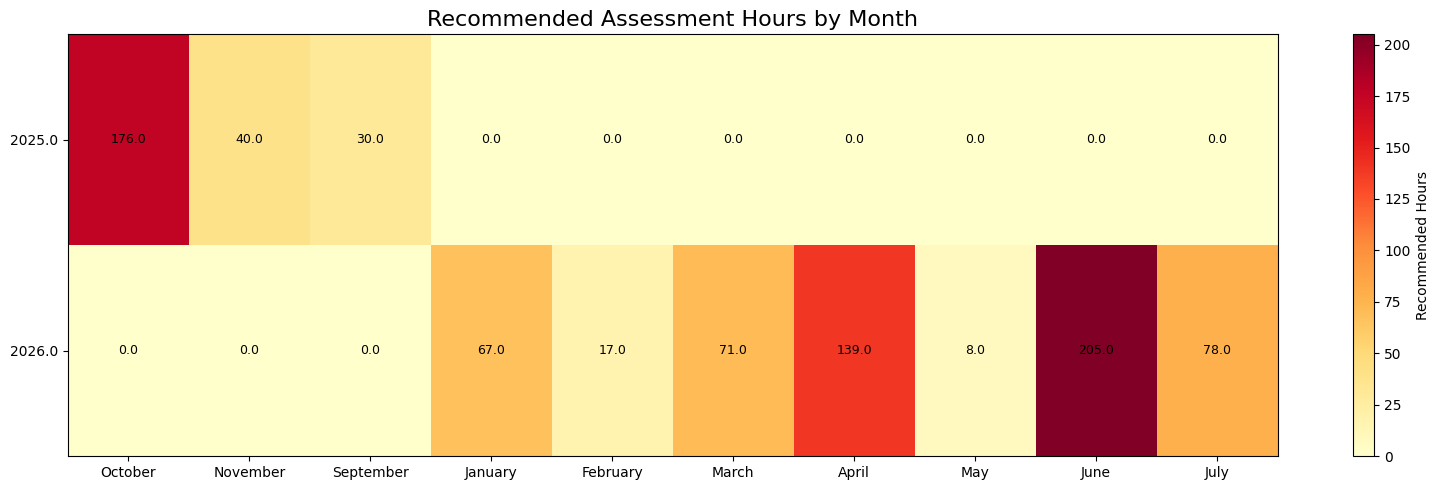

In [140]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 5))

im = ax.imshow(heat_matrix.values, cmap="YlOrRd", aspect="auto")

# X labels
ax.set_xticks(np.arange(len(heat_matrix.columns)))
ax.set_xticklabels(heat_matrix.columns, rotation=0)

# Y labels
ax.set_yticks(np.arange(len(heat_matrix.index)))
ax.set_yticklabels(heat_matrix.index)

# Title
ax.set_title("Recommended Assessment Hours by Month", fontsize=16)

# 🔥 Add data labels
for i in range(heat_matrix.shape[0]):
    for j in range(heat_matrix.shape[1]):
        value = heat_matrix.values[i, j]
        ax.text(
            j, i, f"{value:.1f}", ha="center", va="center", fontsize=9, color="black"
        )

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Recommended Hours")

plt.tight_layout()
plt.show()

In [141]:
df = pd.read_csv("data\\weekly_breakdown_by_year(in).csv")
df.head()

,year,week,start_date,end_date,planned_hours
0,Year 1,1,29-Sep-25,05-Oct-25,0.0
1,Year 1,2,06-Oct-25,12-Oct-25,0.0
2,Year 1,3,13-Oct-25,19-Oct-25,3.3
3,Year 1,4,20-Oct-25,26-Oct-25,3.3
4,Year 1,5,27-Oct-25,02-Nov-25,3.3


In [142]:
# filter end date to less than June 2026
df = df[df["end_date"] < "2026-05-01"]

In [143]:
df["start_date"] = pd.to_datetime(df["start_date"], format="%d-%b-%y")
df["end_date"] = pd.to_datetime(df["end_date"], format="%d-%b-%y")

In [144]:
rows = []

for _, r in df.iterrows():
    weeks = pd.date_range(r["start_date"], r["end_date"], freq="W-MON")

    hours_per_week = r["planned_hours"] / max(len(weeks), 1)

    for w in weeks:
        rows.append({"week": w, "hours": hours_per_week})

df_weekly = pd.DataFrame(rows)

In [145]:
weekly_workload = df_weekly.groupby("week", as_index=False)["hours"].sum()

In [146]:
weekly_workload["label"] = weekly_workload["week"].dt.strftime("%d %b %Y")

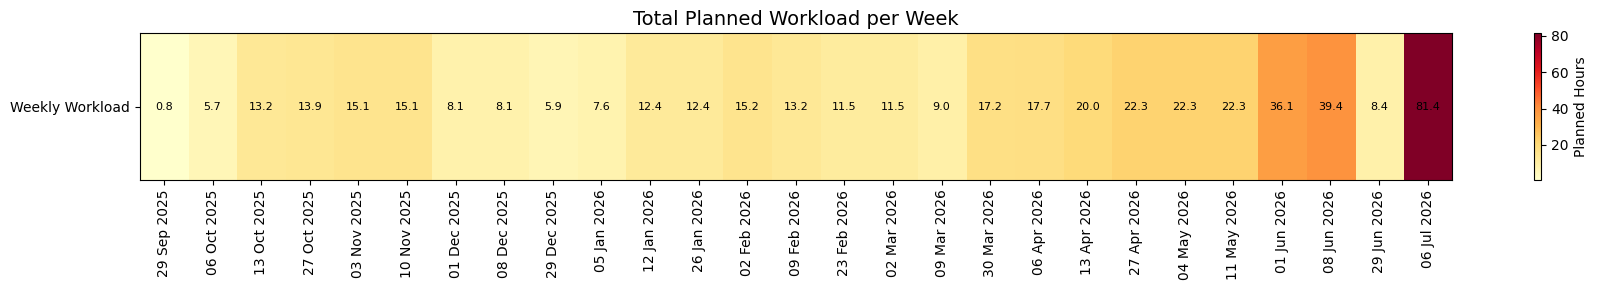

In [147]:
heatmap_values = weekly_workload["hours"].values.reshape(1, -1)

fig, ax = plt.subplots(figsize=(18, 3))

im = ax.imshow(heatmap_values, cmap="YlOrRd", aspect="auto")

# X axis
ax.set_xticks(np.arange(len(weekly_workload)))
ax.set_xticklabels(weekly_workload["label"], rotation=90)

# Y axis
ax.set_yticks([0])
ax.set_yticklabels(["Weekly Workload"])

# Add data labels
for i, val in enumerate(weekly_workload["hours"]):
    ax.text(i, 0, f"{val:.1f}", ha="center", va="center", fontsize=8, color="black")

# Title
ax.set_title("Total Planned Workload per Week", fontsize=14)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Planned Hours")

plt.tight_layout()
plt.show()